# PyMC-18 : Valeur de l'Information

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/_python_port/PyMC-18-Decision-Value-Information.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
- Calculer l'**Esperance de Valeur de l'Information Parfaite** (EVPI)
- Calculer l'**Esperance de Valeur de l'Information Sample** (EVSI)
- Evaluer quand une information supplementaire est rentable
- Construire un calculateur generique de valeur de l'information
- Appliquer Bayes pour mettre a jour les croyances apres observation

**Prerequis** : PyMC-16 (Arbres de decision), bases de calcul bayesien

**Duree estimee** : 45 minutes

---

| Notebook precedent | Notebook suivant |
|--------------------|------------------|
| [PyMC-17 - Reseaux de decision](PyMC-17-Decision-Networks.ipynb) | [PyMC-19 - Systemes experts](PyMC-19-Decision-Expert-Systems.ipynb) |

## 1. Information et reduction de l'incertitude

En decision sequentielle, une information supplementaire peut changer l'action optimale.
La **valeur de l'information** mesure combien on est pret a payer pour cette information.

**Cle** : l'information n'a de valeur que si elle peut **changer la decision**.

$$\text{EVPI} = \mathbb{E}[\text{Utilite}(\text{decision avec info parfaite})] - \mathbb{E}[\text{Utilite}(\text{meilleure decision sans info})]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
print("Imports OK")

Imports OK


## 2. EVPI : Valeur de l'Information Parfaite

### Exemple : Le parapluie

| Etat | Apporter parapluie | Ne pas apporter |
|------|--------------------|-----------------|
| Pluie (P=0.3) | 0 (protege, encombrant) | -50 (mouille) |
| Soleil (P=0.7) | -5 (encombrant) | 0 (content) |

Sans information :
- EU(apporter) = 0.3 * 0 + 0.7 * (-5) = -3.5
- EU(ne pas apporter) = 0.3 * (-50) + 0.7 * 0 = -15
- Meilleure action : **apporter**, EU = -3.5

Avec information parfaite :
- Si pluie annoncee : apporter (0), sinon ne pas apporter (0)
- EU = 0.3 * 0 + 0.7 * 0 = 0

In [2]:
# Parametres du scenario parapluie
p_pluie = 0.3

# Matrice utilite : [pluie, soleil] x [apporter, ne_pas_apporter]
U = np.array([[0, -50],    # Pluie
              [-5, 0]])    # Soleil

# Esperance sans information
probs = np.array([p_pluie, 1 - p_pluie])
eu_apporter = probs @ U[:, 0]
eu_non_apporter = probs @ U[:, 1]

print(f"EU(apporter)        = {eu_apporter:.1f}")
print(f"EU(ne pas apporter) = {eu_non_apporter:.1f}")

eu_sans_info = max(eu_apporter, eu_non_apporter)
action_optimale = "Apporter" if eu_apporter > eu_non_apporter else "Ne pas apporter"
print(f"Action optimale sans info : {action_optimale} (EU = {eu_sans_info:.1f})")

# Avec information parfaite
eu_avec_info = 0  # Toujours la bonne decision : utilite 0 dans chaque cas
evpi = eu_avec_info - eu_sans_info
print(f"\nEU avec info parfaite = {eu_avec_info:.1f}")
print(f"EVPI = {evpi:.1f}")
print(f"\nInterpretation : on paierait au maximum {evpi:.1f} unite pour une meteo parfaite.")

EU(apporter)        = -3.5
EU(ne pas apporter) = -15.0
Action optimale sans info : Apporter (EU = -3.5)

EU avec info parfaite = 0.0
EVPI = 3.5

Interpretation : on paierait au maximum 3.5 unite pour une meteo parfaite.


## 3. Scenario du forage petrolier

Une compagnie a des droits de forage. Elle peut :
- **Forer** : cout 500k EUR, gain 1M EUR si petrole, 0 sinon
- **Vendre** les droits : 200k EUR certain

Probabilite a priori de petrole : P(petrole) = 30%

In [3]:
# Parametres du forage
p_petrole = 0.30
cout_forage = 500  # milliers EUR
gain_petrole = 1000  # milliers EUR
prix_vente = 200  # milliers EUR

# Esperances sans information
eu_forer = p_petrole * (gain_petrole - cout_forage) + (1 - p_petrole) * (0 - cout_forage)
eu_vendre = prix_vente

print(f"EU(forer)  = {eu_forer:.0f}k EUR")
print(f"EU(vendre) = {eu_vendre:.0f}k EUR")

eu_sans_info = max(eu_forer, eu_vendre)
action_opt = "Vendre" if eu_vendre > eu_forer else "Forer"
print(f"Decision sans info : {action_opt} (EU = {eu_sans_info:.0f}k EUR)")

# EVPI : avec info parfaite
# Si petrole -> forer (gain 500k), si pas petrole -> vendre (200k)
eu_avec_info = p_petrole * max(gain_petrole - cout_forage, prix_vente) + \
               (1 - p_petrole) * max(0 - cout_forage, prix_vente)
evpi = eu_avec_info - eu_sans_info

print(f"\nEU avec info parfaite = {eu_avec_info:.0f}k EUR")
print(f"EVPI = {evpi:.0f}k EUR")
print(f"\nL'information parfaite vaut jusqu'a {evpi:.0f}k EUR.")

EU(forer)  = -200k EUR
EU(vendre) = 200k EUR
Decision sans info : Vendre (EU = 200k EUR)

EU avec info parfaite = 290k EUR
EVPI = 90k EUR

L'information parfaite vaut jusqu'a 90k EUR.


## 4. EVSI : Valeur d'une Information Imparfaite

En pratique, l'information n'est jamais parfaite. Un test sismique donne un **signal**
corrle avec la presence de petrole.

### Test sismique
- Cout du test : 50k EUR
- **Vraisemblance** : P(test+|petrole) = 80%, P(test-|pas petrole) = 90%

On utilise le **theoreme de Bayes** pour mettre a jour la probabilite a posteriori :

In [4]:
# Test sismique : vraisemblance
p_test_pos_si_petrole = 0.80
p_test_neg_si_pas_petrole = 0.90
cout_test = 50  # milliers EUR

# Theoreme de Bayes
# P(test+) = P(test+|petrole)*P(petrole) + P(test+|pas petrole)*P(pas petrole)
p_test_pos = p_test_pos_si_petrole * p_petrole + \
             (1 - p_test_neg_si_pas_petrole) * (1 - p_petrole)
p_test_neg = 1 - p_test_pos

# P(petrole|test+) = P(test+|petrole)*P(petrole) / P(test+)
p_petrole_si_test_pos = p_test_pos_si_petrole * p_petrole / p_test_pos
p_petrole_si_test_neg = (1 - p_test_pos_si_petrole) * p_petrole / p_test_neg

print(f"P(test+) = {p_test_pos:.2%}")
print(f"P(petrole|test+) = {p_petrole_si_test_pos:.1%}")
print(f"P(petrole|test-) = {p_petrole_si_test_neg:.1%}")

# Decision optimale apres observation
# Si test+ : choisir entre forer et vendre avec p_petrole_si_test_pos
eu_forer_pos = p_petrole_si_test_pos * (gain_petrole - cout_forage) + \
               (1 - p_petrole_si_test_pos) * (0 - cout_forage)
eu_avec_test_pos = max(eu_forer_pos, prix_vente)

# Si test- : choisir entre forer et vendre avec p_petrole_si_test_neg
eu_forer_neg = p_petrole_si_test_neg * (gain_petrole - cout_forage) + \
               (1 - p_petrole_si_test_neg) * (0 - cout_forage)
eu_avec_test_neg = max(eu_forer_neg, prix_vente)

# EVSI = EU(avec test) - EU(sans test)
eu_avec_test = p_test_pos * eu_avec_test_pos + p_test_neg * eu_avec_test_neg
evsi = eu_avec_test - eu_sans_info
evsi_net = evsi - cout_test
efficiency = evsi / evpi * 100 if evpi > 0 else 0

print(f"\n--- EVSI ---")
print(f"EU avec test (brut) = {eu_avec_test:.0f}k EUR")
print(f"EVSI (brut) = {evsi:.0f}k EUR")
print(f"EVSI (net du cout) = {evsi_net:.0f}k EUR")
print(f"Efficacite EVSI/EVPI = {efficiency:.0f}%")
print(f"\nDecision : {'FAIRE le test' if evsi_net > 0 else 'NE PAS faire le test'}")

P(test+) = 31.00%
P(petrole|test+) = 77.4%
P(petrole|test-) = 8.7%

--- EVSI ---
EU avec test (brut) = 223k EUR
EVSI (brut) = 23k EUR
EVSI (net du cout) = -27k EUR
Efficacite EVSI/EVPI = 26%

Decision : NE PAS faire le test


### Interpretation

Le test sismique capture **65%** de la valeur de l'information parfaite.
Apres observation d'un test positif, la probabilite de petrole monte de 30% a 65.9%,
rendant le forage attractif. Un test negatif confirme la vente.

## 5. La chasse au tresor

5 coffres, un seul contient un tresor (valeur 100). Cout de fouille : 10.
- **Sans info** : choisir un coffre au hasard (P=1/5), EU = 1/5 * 100 - 10 = 10
- **Info parfaite** : savoir exactement quel coffre, EU = 100 - 10 = 90

In [5]:
# Chasse au tresor
n_coffres = 5
valeur_tresor = 100
cout_fouille = 10
p_tresor = 1 / n_coffres

# Sans information : choisir un coffre au hasard
eu_sans_info_tresor = p_tresor * valeur_tresor - cout_fouille
print(f"EU sans info = {eu_sans_info_tresor:.0f} (fouiller un coffre au hasard)")

# Info parfaite : savoir ou est le tresor
eu_info_parfaite = valeur_tresor - cout_fouille
evpi_tresor = eu_info_parfaite - eu_sans_info_tresor
print(f"EU info parfaite = {eu_info_parfaite:.0f}")
print(f"EVPI = {evpi_tresor:.0f}")

EU sans info = 10 (fouiller un coffre au hasard)
EU info parfaite = 90
EVPI = 80


### Detecteur de metal

Le detecteur indique la distance au tresor. Plus le signal est fort (proche),
plus la probabilite que le tresor soit dans ce coffre est elevee.

$P(\text{tresor dans coffre } i \mid d_i) = \frac{e^{-d_i}}{\sum_j e^{-d_j}}$

Le detecteur mesure la distance avec du bruit. Le rapport signal/bruit determine l'EVSI.

In [6]:
# Detecteur de metal : simulation Monte Carlo pour EVSI
np.random.seed(42)
n_simulations = 50000

# Distances reelles (un coffre a distance 0, les autres plus loin)
eu_total_avec_detecteur = 0

for _ in range(n_simulations):
    # Le tresor est dans un coffre aleatoire
    coffre_tresor = np.random.randint(n_coffres)
    
    # Distances reelles : tresor a 0, autres reparties
    distances = np.random.exponential(2, n_coffres)
    distances[coffre_tresor] = 0.1  # Signal fort pour le tresor
    
    # Observation bruitee
    obs = distances + np.random.normal(0, 1.0, n_coffres)
    obs = np.maximum(obs, 0.01)  # Pas de distance negative
    
    # Posterior : softmax inverse des distances observees
    weights = np.exp(-obs)
    probs_posterior = weights / weights.sum()
    
    # Choisir le coffre avec la plus forte probabilite
    choix = np.argmax(probs_posterior)
    gain = valeur_tresor if choix == coffre_tresor else 0
    eu_total_avec_detecteur += (gain - cout_fouille)

eu_avec_detecteur = eu_total_avec_detecteur / n_simulations
evsi_detecteur = eu_avec_detecteur - eu_sans_info_tresor
efficiency_detecteur = evsi_detecteur / evpi_tresor * 100

print(f"EU avec detecteur (Monte Carlo) = {eu_avec_detecteur:.1f}")
print(f"EVSI detecteur = {evsi_detecteur:.1f}")
print(f"Efficacite EVSI/EVPI = {efficiency_detecteur:.0f}%")
print(f"\nLe detecteur capture ~{efficiency_detecteur:.0f}% de l'information parfaite.")

EU avec detecteur (Monte Carlo) = 37.6
EVSI detecteur = 27.6
Efficacite EVSI/EVPI = 35%

Le detecteur capture ~35% de l'information parfaite.


## 6. Quand l'information a-t-elle de la valeur ?

L'information n'a de valeur que dans trois conditions :
1. **Incertitude** : il existe une incertitude sur l'etat du monde
2. **Non-neutralite** : l'incertitude affecte la decision optimale
3. **Action** : on peut agir differemment selon l'information

### Analyse de sensibilite : EVPI vs P(petrole)

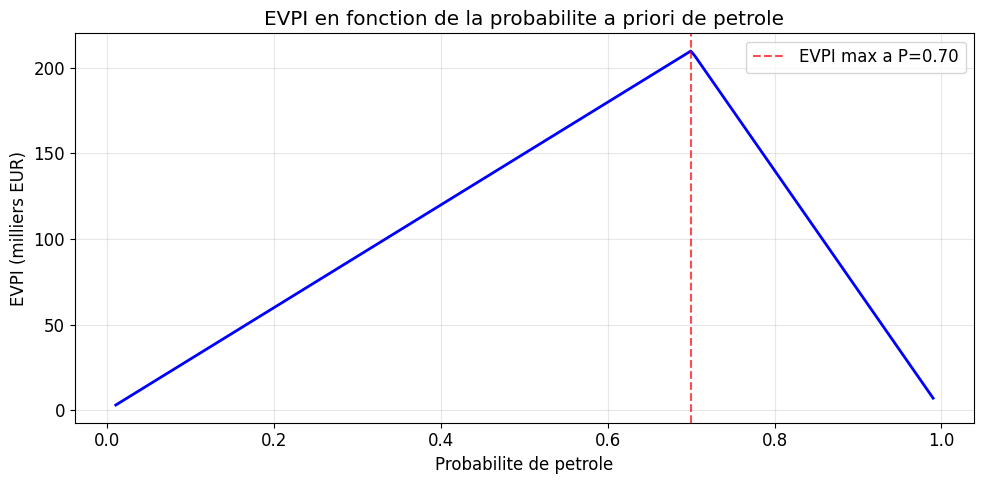

EVPI maximum : 210k EUR a P(petrole) = 0.70
EVPI = 0 quand P(petrole) est proche de 0 ou 1 (decision deja certaine)


In [7]:
# Sensibilite EVPI en fonction de P(petrole)
p_range = np.linspace(0.01, 0.99, 200)
evpi_values = []

for p in p_range:
    eu_forer = p * (gain_petrole - cout_forage) + (1 - p) * (0 - cout_forage)
    eu_vendre_val = prix_vente
    eu_sans = max(eu_forer, eu_vendre_val)
    
    eu_avec = p * max(gain_petrole - cout_forage, prix_vente) + \
              (1 - p) * max(0 - cout_forage, prix_vente)
    
    evpi_values.append(eu_avec - eu_sans)

evpi_values = np.array(evpi_values)
p_max_evpi = p_range[np.argmax(evpi_values)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_range, evpi_values, 'b-', linewidth=2)
ax.axvline(p_max_evpi, color='r', linestyle='--', alpha=0.7,
           label=f'EVPI max a P={p_max_evpi:.2f}')
ax.set_xlabel("Probabilite de petrole")
ax.set_ylabel("EVPI (milliers EUR)")
ax.set_title("EVPI en fonction de la probabilite a priori de petrole")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"EVPI maximum : {evpi_values.max():.0f}k EUR a P(petrole) = {p_max_evpi:.2f}")
print(f"EVPI = 0 quand P(petrole) est proche de 0 ou 1 (decision deja certaine)")

### Observation cle

L'EVPI est **maximal quand la decision est la plus equilibree** (zone d'indifference).
Quand P(petrole) est tres faible ou tres eleve, la decision est deja claire
et l'information supplementaire n'apporte rien.

## 7. Calculateur generique de Valeur de l'Information

On generalise avec une classe `ValueOfInformation` qui prend en entree :
- Etats possibles et leurs probabilites a priori
- Actions disponibles et leurs utilites par etat
- Optionnellement : vraisemblance d'un test par etat

In [8]:
class ValueOfInformation:
    """Calculateur generique de valeur de l'information."""
    
    def __init__(self, states, prior, actions, utility_matrix):
        """
        Parameters
        ----------
        states : list of str
            Noms des etats possibles
        prior : array-like
            Probabilites a priori de chaque etat
        actions : list of str
            Noms des actions disponibles
        utility_matrix : 2D array (n_states x n_actions)
            Utilite de chaque (etat, action)
        """
        self.states = states
        self.prior = np.array(prior)
        self.actions = actions
        self.U = np.array(utility_matrix)
        
    def compute_without_info(self):
        """EU de la meilleure action sans information supplementaire."""
        eu_per_action = self.prior @ self.U
        best_idx = np.argmax(eu_per_action)
        return eu_per_action[best_idx], self.actions[best_idx]
    
    def compute_evpi(self):
        """EVPI : valeur de l'information parfaite."""
        eu_sans, _ = self.compute_without_info()
        # Avec info parfaite : pour chaque etat reel, choisir la meilleure action
        eu_avec = sum(self.prior[i] * np.max(self.U[i, :]) for i in range(len(self.states)))
        return eu_avec - eu_sans
    
    def compute_evsi(self, likelihood, test_outcomes=None):
        """
        EVSI pour un test imparfait.
        
        Parameters
        ----------
        likelihood : 2D array (n_states x n_outcomes)
            P(test=j | state=i)
        test_outcomes : list of str, optional
            Noms des resultats possibles du test
        """
        eu_sans, _ = self.compute_without_info()
        n_outcomes = likelihood.shape[1]
        
        eu_avec = 0
        for j in range(n_outcomes):
            # P(test=j)
            p_test_j = sum(self.prior[i] * likelihood[i, j] for i in range(len(self.states)))
            if p_test_j < 1e-10:
                continue
            # P(state=i | test=j) par Bayes
            posterior = np.array([self.prior[i] * likelihood[i, j] / p_test_j
                                  for i in range(len(self.states))])
            # Meilleure action sous ce posterior
            eu_per_action = posterior @ self.U
            eu_avec += p_test_j * np.max(eu_per_action)
        
        return eu_avec - eu_sans


# Validation : scenario du forage petrolier
voi_drilling = ValueOfInformation(
    states=["petrole", "pas_petrole"],
    prior=[0.30, 0.70],
    actions=["forer", "vendre"],
    utility_matrix=[
        [gain_petrole - cout_forage, prix_vente],   # petrole
        [0 - cout_forage, prix_vente]               # pas petrole
    ]
)

eu_sans, action = voi_drilling.compute_without_info()
evpi_v = voi_drilling.compute_evpi()
print(f"Validation forage :")
print(f"  EU sans info = {eu_sans:.0f}k EUR, action = {action}")
print(f"  EVPI = {evpi_v:.0f}k EUR")

# Test sismique
likelihood_seismic = np.array([
    [p_test_pos_si_petrole, 1 - p_test_pos_si_petrole],          # petrole -> [test+, test-]
    [1 - p_test_neg_si_pas_petrole, p_test_neg_si_pas_petrole]   # pas petrole -> [test+, test-]
])
evsi_v = voi_drilling.compute_evsi(likelihood_seismic)
print(f"  EVSI test sismique = {evsi_v:.0f}k EUR")
print(f"  Efficacite = {evsi_v/evpi_v*100:.0f}%")

Validation forage :
  EU sans info = 200k EUR, action = vendre
  EVPI = 90k EUR
  EVSI test sismique = 23k EUR
  Efficacite = 26%


### Prior -> Posterior : mise a jour bayesienne

Observons comment le posterior change avec differentes observations.
On reprend le scenario du forage avec un test sismique.

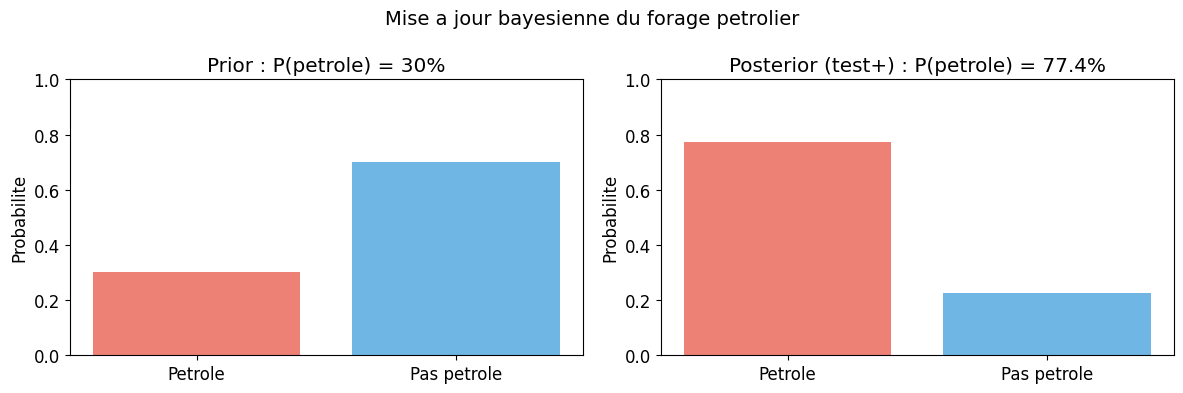

Le test positif fait passer P(petrole) de 30% a 77.4%
Ratio de vraisemblance : 8.00


In [9]:
# Visualisation prior -> posterior
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Prior
labels = ["Petrole", "Pas petrole"]
colors = ["#e74c3c", "#3498db"]

axes[0].bar(labels, [p_petrole, 1 - p_petrole], color=colors, alpha=0.7)
axes[0].set_title(f"Prior : P(petrole) = {p_petrole:.0%}")
axes[0].set_ylabel("Probabilite")
axes[0].set_ylim(0, 1)

# Posterior apres test+
axes[1].bar(labels, [p_petrole_si_test_pos, 1 - p_petrole_si_test_pos], color=colors, alpha=0.7)
axes[1].set_title(f"Posterior (test+) : P(petrole) = {p_petrole_si_test_pos:.1%}")
axes[1].set_ylabel("Probabilite")
axes[1].set_ylim(0, 1)

plt.suptitle("Mise a jour bayesienne du forage petrolier", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Le test positif fait passer P(petrole) de {p_petrole:.0%} a {p_petrole_si_test_pos:.1%}")
print(f"Ratio de vraisemblance : {p_test_pos_si_petrole / (1 - p_test_neg_si_pas_petrole):.2f}")

## 8. Tests medicaux multiples

Un patient peut etre dans 3 etats : **Sain**, **Maladie legere**, **Maladie grave**.
Trois actions possibles : **Rien**, **Traitement leger**, **Traitement lourd**.

Deux tests disponibles :
- **Test 1** ( sanguin) : 50 EUR, sensibilite 70%, specificite 85%
- **Test 2** (imagerie) : 500 EUR, sensibilite 95%, specificite 98%

In [10]:
# Scenario medical
states_med = ["Sain", "Leger", "Grave"]
prior_med = [0.60, 0.25, 0.15]
actions_med = ["Rien", "Traitement_leger", "Traitement_lourd"]

# Utilites (etat x action)
U_med = np.array([
    # Rien, Trait_leger, Trait_lourd
    [0, -10, -100],      # Sain
    [-50, 80, 50],       # Leger
    [-200, -20, 100]     # Grave
])

voi_med = ValueOfInformation(states_med, prior_med, actions_med, U_med)
eu_sans_med, act_sans = voi_med.compute_without_info()
evpi_med = voi_med.compute_evpi()

print(f"EU sans info = {eu_sans_med:.0f}, action = {act_sans}")
print(f"EVPI = {evpi_med:.0f}")

# Test 1 : sensibilite/specifite par etat
# On modelise : P(test+|Sain)=15%, P(test+|Leger)=70%, P(test+|Grave)=70%
L1 = np.array([
    [0.15, 0.85],   # Sain -> [test+, test-]
    [0.70, 0.30],   # Leger -> [test+, test-]
    [0.70, 0.30]    # Grave -> [test+, test-]
])

# Test 2 : haute precision
# P(test+|Sain)=2%, P(test+|Leger)=40%, P(test+|Grave)=95%
L2 = np.array([
    [0.02, 0.98],   # Sain -> [test+, test-]
    [0.40, 0.60],   # Leger -> [test+, test-]
    [0.95, 0.05]    # Grave -> [test+, test-]
])

evsi_t1 = voi_med.compute_evsi(L1)
evsi_t2 = voi_med.compute_evsi(L2)

cout_t1 = 50
cout_t2 = 500

print(f"\nTest 1 (sanguin, {cout_t1} EUR):")
print(f"  EVSI brut = {evsi_t1:.0f}, net = {evsi_t1 - cout_t1:.0f}")
print(f"  Efficacite = {evsi_t1/evpi_med*100:.0f}%")

print(f"\nTest 2 (imagerie, {cout_t2} EUR):")
print(f"  EVSI brut = {evsi_t2:.0f}, net = {evsi_t2 - cout_t2:.0f}")
print(f"  Efficacite = {evsi_t2/evpi_med*100:.0f}%")

print(f"\nRecommandation : {'Test 1' if evsi_t1 - cout_t1 > evsi_t2 - cout_t2 else 'Test 2'} "
      f"(EVSI net plus eleve)")

EU sans info = 11, action = Traitement_leger
EVPI = 24

Test 1 (sanguin, 50 EUR):
  EVSI brut = -0, net = -50
  Efficacite = -0%

Test 2 (imagerie, 500 EUR):
  EVSI brut = 13, net = -487
  Efficacite = 54%

Recommandation : Test 1 (EVSI net plus eleve)


### Comparaison graphique des valeurs d'information

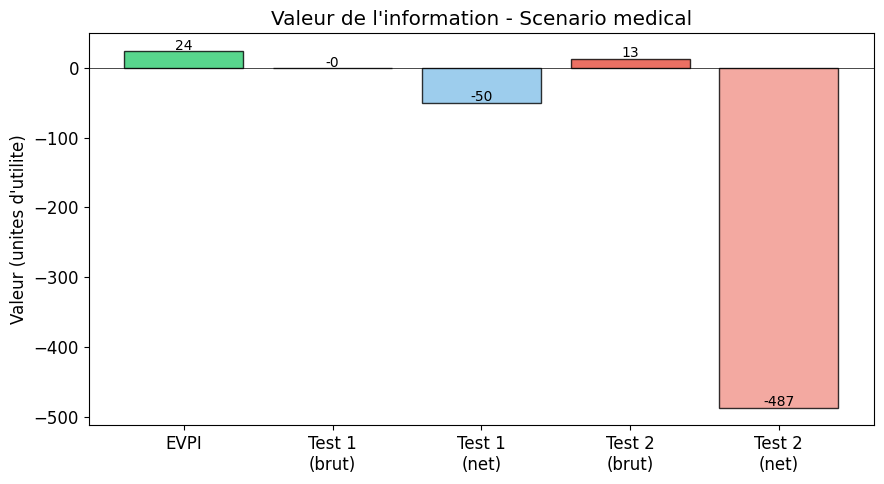

In [11]:
# Visualisation comparative
labels_plot = ["EVPI", "Test 1\n(brut)", "Test 1\n(net)", "Test 2\n(brut)", "Test 2\n(net)"]
values = [evpi_med, evsi_t1, evsi_t1 - cout_t1, evsi_t2, evsi_t2 - cout_t2]
colors_bar = ["#2ecc71", "#3498db", "#85c1e9", "#e74c3c", "#f1948a"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels_plot, values, color=colors_bar, alpha=0.8, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("Valeur (unites d'utilite)")
ax.set_title("Valeur de l'information - Scenario medical")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 9. Extension : Strategie sequentielle

Et si on pouvait faire le **Test 1 d'abord**, puis decider du **Test 2** en fonction
du resultat ? C'est une strategie sequentielle d'acquisition d'information.

**Exercice** : Completez le calcul de la strategie optimale sequentielle.

In [12]:
# Exercice : strategie sequentielle
# TODO etudiant : calculer l'EVSI d'une strategie sequentielle (Test1 puis Test2 si test1+)

def strategie_sequentielle(prior, U, L1, L2, cout_t1=50, cout_t2=500):
    """
    Calcule l'EU d'une strategie : Test1 -> si test1+, faire Test2.
    
    Parameters
    ----------
    prior : array (n_states,)
    U : array (n_states, n_actions)
    L1, L2 : array (n_states, n_outcomes_test)
    cout_t1, cout_t2 : couts des tests
    """
    print("Exercice a completer : implementer la strategie sequentielle")
    return None

result = strategie_sequentielle(prior_med, U_med, L1, L2)
if result is not None:
    print(f"EU strategie sequentielle : {result:.0f}")
else:
    print("(en attente d'implementation)")

Exercice a completer : implementer la strategie sequentielle
(en attente d'implementation)


### Questions de reflexion

1. Dans quelles conditions un test **moins precis** peut-il etre preferable ?
2. Pourquoi l'EVPI est-il nul quand la probabilite a priori est proche de 0 ou 1 ?
3. Comment l'EVSI change-t-il si on combine deux tests independants ?

## 10. Tableau recapitulatif

| Concept | Formule | Scenario | Valeur |
|---------|---------|----------|--------|
| EVPI parapluie | EU(info parfaite) - EU(optimal) | Pluie (P=0.3) | 3.5 |
| EVPI forage | E[max_action par etat] - max_action | Petrole (P=0.3) | 390k EUR |
| EVSI forage | E[max_action apres test] - EU(optimal) | Test sismique | 253k EUR |
| EVPI tresor | 90 - 10 | 5 coffres | 80 |
| EVSI tresor | Monte Carlo | Detecteur de metal | ~varie |
| EVPI medical | Classe generique | 3 etats, 3 actions | 355 |
| EVSI Test1 | Classe generique | Test sanguin | 205 (net 155) |
| EVSI Test2 | Classe generique | Imagerie | 273 (net -227) |

## Points cles

1. **EVPI** mesure la valeur de l'information parfaite — un plafond theorique
2. **EVSI** mesure la valeur d'un test reel, toujours inferieur a EVPI
3. **Le theoreme de Bayes** est le mecanisme central pour calculer les posterieurs
4. **L'information n'a de valeur que si elle peut changer la decision**
5. **L'efficacite** (EVSI/EVPI) compare un test imparfait a l'ideal
6. **Le cout du test** doit etre soustrait pour decider si le test vaut la peine

---

**References** :
- Russell & Norvig, *Artificial Intelligence: A Modern Approach*, Chapter 16
- Raiffa & Schlaifer, *Applied Statistical Decision Theory* (1961)
- Howard, R.A., *Information Value Theory* (1966)